<a href="https://colab.research.google.com/github/castrokelly/PPGIa/blob/main/atividade_A_classificacao_breast_cancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atividade A - Classificação do Breast Cancer Wisconsin (Diagnostic)

**Objetivo:** treinar, ajustar e comparar modelos de classificação para distinguir tumores
**malignos (0)** e **benignos (1)** usando validação cruzada estratificada com 5 folds.

Modelos exigidos pela atividade:

- Árvore de Decisão
- KNN
- Naive Bayes
- SVM
- MLP
- Random Forest
- Bagging
- AdaBoost
- XGBoost

Ao final, o notebook responde:

- **A.1:** taxa de acerto de cada classe;
- **A.2:** matriz de confusão;
- **A.3:** parâmetros do melhor modelo;
- **A.4:** comparação entre acurácia e F1-score.

## Planejamento da resolução

1. Instalar e importar as bibliotecas.
2. Carregar a base pela API `ucimlrepo`.
3. Confirmar quantidade de instâncias, atributos, classes e valores ausentes.
4. Converter o alvo para a codificação pedida: `0 = maligno` e `1 = benigno`.
5. Criar pipelines para evitar vazamento de dados durante a padronização.
6. Usar validação cruzada estratificada com 5 folds.
7. Ajustar hiperparâmetros com `GridSearchCV`.
8. Comparar acurácia, F1 ponderado, precisão ponderada e recall ponderado.
9. Selecionar o melhor modelo pelo F1 ponderado.
10. Gerar predições fora da amostra com `cross_val_predict`.
11. Calcular matriz de confusão e taxa de acerto de cada classe.
12. Registrar os parâmetros e redigir as respostas finais.

## 1. Instalação

Instalando `ucimlrepo` para importar a base diretamente
do repositório UCI e `xgboost` para o último ensemble.

In [1]:
%pip install -q ucimlrepo xgboost

## 2. Importações e configuração

O valor fixo de `RANDOM_STATE` torna os resultados reproduzíveis.

In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    StratifiedKFold,
    GridSearchCV,
    cross_validate,
    cross_val_predict,
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    make_scorer,
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    BaggingClassifier,
    AdaBoostClassifier,
)
from scipy.stats import ttest_rel

try:
    from xgboost import XGBClassifier
except ImportError as exc:
    raise ImportError(
        "XGBoost não está instalado. Reesecutar célula anterior e reiniciar kernel"
    ) from exc

RANDOM_STATE = 42
N_JOBS = 2  # alterar para 1 em ambientes com poucos recursos
pd.set_option("display.max_colwidth", 120)

## 3. Carregamento da base

A primeira tentativa usa exatamente o procedimento solicitado com `fetch_ucirepo(id=17)`.
Há também um fallback para a cópia da mesma base incluída no Scikit-learn, útil quando
o ambiente está sem acesso à internet.

A base deve possuir:

- 569 instâncias;
- 30 atributos numéricos;
- 212 casos malignos;
- 357 casos benignos.

In [4]:
fonte_dados = None

try:
    from ucimlrepo import fetch_ucirepo

    breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)

    X = breast_cancer_wisconsin_diagnostic.data.features.copy()
    y_original = breast_cancer_wisconsin_diagnostic.data.targets.copy()

    print("Metadados principais:")
    print(breast_cancer_wisconsin_diagnostic.metadata)
    print("\nInformações das variáveis:")
    display(breast_cancer_wisconsin_diagnostic.variables)

    # O alvo da UCI costuma vir como M/B.
    alvo_texto = (
        y_original.iloc[:, 0]
        .astype(str)
        .str.strip()
        .str.upper()
    )
    y = alvo_texto.map({"M": 0, "B": 1})

    if y.isna().any():
        raise ValueError(
            f"Valores inesperados no alvo da UCI: {sorted(alvo_texto.unique())}"
        )

    y = y.astype(int)
    fonte_dados = "UCI Machine Learning Repository via ucimlrepo"

except Exception as erro_uci:
    print("Não foi possível carregar pela UCI. Usando a cópia do Scikit-learn.")
    print("Motivo:", erro_uci)

    from sklearn.datasets import load_breast_cancer

    X, y = load_breast_cancer(return_X_y=True, as_frame=True)
    y = y.astype(int)
    fonte_dados = "Scikit-learn load_breast_cancer"

print("\nFonte utilizada:", fonte_dados)
print("Dimensão de X:", X.shape)
print("Dimensão de y:", y.shape)

Metadados principais:
{'uci_id': 17, 'name': 'Breast Cancer Wisconsin (Diagnostic)', 'repository_url': 'https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic', 'data_url': 'https://archive.ics.uci.edu/static/public/17/data.csv', 'abstract': 'Diagnostic Wisconsin Breast Cancer Database.', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 569, 'num_features': 30, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Diagnosis'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1993, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C5DW2B', 'creators': ['William Wolberg', 'Olvi Mangasarian', 'Nick Street', 'W. Street'], 'intro_paper': {'ID': 230, 'type': 'NATIVE', 'title': 'Nuclear feature extraction for breast tumor diagnosis', 'authors': 'W. Street, W. Wolberg, O. Mangasarian', 'venue': 'Electronic imaging', 'year': 1993, 'jou

,name,role,type,demographic,description,units,missing_values
0,ID,ID,Categorical,None,None,None,no
1,Diagnosis,Target,Categorical,None,None,None,no
2,radius1,Feature,Continuous,None,None,None,no
3,texture1,Feature,Continuous,None,None,None,no
4,perimeter1,Feature,Continuous,None,None,None,no
5,area1,Feature,Continuous,None,None,None,no
6,smoothness1,Feature,Continuous,None,None,None,no
7,compactness1,Feature,Continuous,None,None,None,no
8,concavity1,Feature,Continuous,None,None,None,no
9,concave_points1,Feature,Continuous,None,None,None,no



Fonte utilizada: UCI Machine Learning Repository via ucimlrepo
Dimensão de X: (569, 30)
Dimensão de y: (569,)


## 4. Auditoria inicial dos dados

Antes do treinamento, confirmando:

- formato `(569, 30)`;
- ausência de valores nulos;
- classes `0` e `1`;
- distribuição `212 malignos` e `357 benignos`.

In [5]:
resumo_base = pd.DataFrame({
    "informação": [
        "Número de instâncias",
        "Número de atributos",
        "Valores ausentes em X",
        "Valores ausentes em y",
        "Menor valor do alvo",
        "Maior valor do alvo",
    ],
    "valor": [
        X.shape[0],
        X.shape[1],
        int(X.isna().sum().sum()),
        int(pd.Series(y).isna().sum()),
        int(pd.Series(y).min()),
        int(pd.Series(y).max()),
    ],
})

display(resumo_base)
display(X.head())

distribuicao = (
    pd.Series(y)
    .value_counts()
    .sort_index()
    .rename(index={0: "Maligno (0)", 1: "Benigno (1)"})
    .to_frame("quantidade")
)
display(distribuicao)

assert X.shape == (569, 30), f"Dimensão inesperada: {X.shape}"
assert set(pd.Series(y).unique()) == {0, 1}
assert int((pd.Series(y) == 0).sum()) == 212
assert int((pd.Series(y) == 1).sum()) == 357
assert X.isna().sum().sum() == 0

,informação,valor
0,Número de instâncias,569
1,Número de atributos,30
2,Valores ausentes em X,0
3,Valores ausentes em y,0
4,Menor valor do alvo,0
5,Maior valor do alvo,1


,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


,quantidade
Diagnosis,
Maligno (0),212
Benigno (1),357


## 5. Protocolo experimental e métricas

A validação cruzada é **estratificada** para preservar aproximadamente a proporção das
classes em cada fold.

Como `1` representa benigno, se usarmos apenas o F1 binário padrão dariamos ênfase à classe benigna.
Por isso, o notebook usa métricas **ponderadas**, que consideram as duas classes:

- acurácia;
- F1 ponderado;
- precisão ponderada;
- recall ponderado.

O melhor modelo será selecionado pelo **F1 ponderado**.

In [6]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

scoring_classificacao = {
    "accuracy": make_scorer(accuracy_score),
    "f1_weighted": make_scorer(
        f1_score,
        average="weighted",
        zero_division=0,
    ),
    "precision_weighted": make_scorer(
        precision_score,
        average="weighted",
        zero_division=0,
    ),
    "recall_weighted": make_scorer(
        recall_score,
        average="weighted",
        zero_division=0,
    ),
}

## 6. Modelos, pipelines e grades de hiperparâmetros

`StandardScaler` é aplicado dentro do pipeline dos modelos sensíveis à escala:

- KNN;
- SVM;
- MLP.

Isso evita vazamento de dados: em cada fold, o padronizador é ajustado somente no
subconjunto de treinamento.

In [8]:
modelos_classificacao = {
    "Árvore de Decisão": {
        "pipeline": Pipeline([
            ("model", DecisionTreeClassifier(random_state=RANDOM_STATE))
        ]),
        "param_grid": {
            "model__criterion": ["gini", "entropy"],
            "model__max_depth": [None, 3, 5, 8],
            "model__min_samples_leaf": [1, 3, 5],
        },
    },
    "KNN": {
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier()),
        ]),
        "param_grid": {
            "model__n_neighbors": [3, 5, 7, 9, 11],
            "model__weights": ["uniform", "distance"],
            "model__p": [1, 2],
        },
    },
    "Naive Bayes": {
        "pipeline": Pipeline([
            ("model", GaussianNB())
        ]),
        "param_grid": {
            "model__var_smoothing": [1e-11, 1e-10, 1e-9, 1e-8, 1e-7],
        },
    },
    "SVM": {
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVC()),
        ]),
        "param_grid": {
            "model__C": [0.1, 1, 10, 100],
            "model__kernel": ["linear", "rbf"],
            "model__gamma": ["scale", "auto"],
        },
    },
    "MLP": {
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("model", MLPClassifier(
                max_iter=2000,
                early_stopping=True,
                random_state=RANDOM_STATE,
            )),
        ]),
        "param_grid": {
            "model__hidden_layer_sizes": [(50,), (100,), (50, 25)],
            "model__activation": ["relu", "tanh"],
            "model__alpha": [0.0001, 0.001],
            "model__learning_rate_init": [0.001, 0.01],
        },
    },
    "Random Forest": {
        "pipeline": Pipeline([
            ("model", RandomForestClassifier(
                random_state=RANDOM_STATE,
                n_jobs=N_JOBS,
            ))
        ]),
        "param_grid": {
            "model__n_estimators": [200, 400],
            "model__max_depth": [None, 5, 10],
            "model__min_samples_leaf": [1, 3],
        },
    },
    "Bagging": {
        "pipeline": Pipeline([
            ("model", BaggingClassifier(
                estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
                random_state=RANDOM_STATE,
                n_jobs=N_JOBS,
            ))
        ]),
        "param_grid": {
            "model__n_estimators": [50, 100],
            "model__max_samples": [0.7, 1.0],
            "model__max_features": [0.7, 1.0],
        },
    },
    "AdaBoost": {
        "pipeline": Pipeline([
            ("model", AdaBoostClassifier(random_state=RANDOM_STATE))
        ]),
        "param_grid": {
            "model__n_estimators": [50, 100, 200],
            "model__learning_rate": [0.01, 0.1, 1.0],
        },
    },
    "XGBoost": {
        "pipeline": Pipeline([
            ("model", XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
                random_state=RANDOM_STATE,
                n_jobs=1,
                verbosity=0,
            ))
        ]),
        "param_grid": {
            "model__n_estimators": [200, 400],
            "model__max_depth": [2, 3, 5],
            "model__learning_rate": [0.03, 0.1],
            "model__subsample": [0.8, 1.0],
            "model__colsample_bytree": [0.8, 1.0],
        },
    },
}

print("Quantidade de indutores:", len(modelos_classificacao))

Quantidade de indutores: 9


## 7. Busca dos melhores hiperparâmetros

Para cada indutor:

1. executar `GridSearchCV`;
2. usa-se a mesma validação cruzada de 5 folds;
3. escolhe-se o conjunto de parâmetros com maior F1 ponderado;
4. registram-se as quatro métricas pedidas.

In [9]:
resultados_classificacao = []
buscas_classificacao = {}

for nome, configuracao in modelos_classificacao.items():
    print(f"Treinando: {nome}")

    busca = GridSearchCV(
        estimator=configuracao["pipeline"],
        param_grid=configuracao["param_grid"],
        scoring=scoring_classificacao,
        refit="f1_weighted",
        cv=cv,
        n_jobs=N_JOBS,
        return_train_score=False,
        error_score="raise",
    )
    busca.fit(X, y)

    melhor_indice = busca.best_index_

    resultados_classificacao.append({
        "Indutor": nome,
        "Acurácia média": busca.cv_results_["mean_test_accuracy"][melhor_indice],
        "Desvio acurácia": busca.cv_results_["std_test_accuracy"][melhor_indice],
        "F1 ponderado": busca.cv_results_["mean_test_f1_weighted"][melhor_indice],
        "Precisão ponderada": busca.cv_results_["mean_test_precision_weighted"][melhor_indice],
        "Recall ponderado": busca.cv_results_["mean_test_recall_weighted"][melhor_indice],
        "Melhores parâmetros": busca.best_params_,
    })

    buscas_classificacao[nome] = busca

tabela_classificacao = (
    pd.DataFrame(resultados_classificacao)
    .sort_values(
        by=["F1 ponderado", "Acurácia média"],
        ascending=False,
    )
    .reset_index(drop=True)
)

tabela_exibicao = tabela_classificacao.copy()
for coluna in [
    "Acurácia média",
    "Desvio acurácia",
    "F1 ponderado",
    "Precisão ponderada",
    "Recall ponderado",
]:
    tabela_exibicao[coluna] = tabela_exibicao[coluna].map(lambda valor: round(valor, 4))

display(tabela_exibicao)

Treinando: Árvore de Decisão
Treinando: KNN
Treinando: Naive Bayes
Treinando: SVM
Treinando: MLP
Treinando: Random Forest
Treinando: Bagging
Treinando: AdaBoost
Treinando: XGBoost


,Indutor,Acurácia média,Desvio acurácia,F1 ponderado,Precisão ponderada,Recall ponderado,Melhores parâmetros
0,SVM,0.9789,0.0119,0.9788,0.9795,0.9789,"{'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'rbf'}"
1,MLP,0.9737,0.0078,0.9735,0.9746,0.9737,"{'model__activation': 'relu', 'model__alpha': 0.0001, 'model__hidden_layer_sizes': (50, 25), 'model__learning_rate_i..."
2,XGBoost,0.9684,0.0070,0.9683,0.9690,0.9684,"{'model__colsample_bytree': 1.0, 'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 400, 'mo..."
3,KNN,0.9684,0.0142,0.9681,0.9697,0.9684,"{'model__n_neighbors': 9, 'model__p': 2, 'model__weights': 'distance'}"
4,AdaBoost,0.9666,0.0151,0.9665,0.9673,0.9666,"{'model__learning_rate': 1.0, 'model__n_estimators': 200}"
5,Bagging,0.9614,0.0172,0.9612,0.9622,0.9614,"{'model__max_features': 0.7, 'model__max_samples': 1.0, 'model__n_estimators': 100}"
6,Random Forest,0.9543,0.0102,0.9542,0.9565,0.9543,"{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 200}"
7,Árvore de Decisão,0.9384,0.0217,0.9385,0.9396,0.9384,"{'model__criterion': 'entropy', 'model__max_depth': None, 'model__min_samples_leaf': 1}"
8,Naive Bayes,0.9385,0.0235,0.9379,0.9413,0.9385,{'model__var_smoothing': 1e-09}


## 8. Visualização comparativa

Gráfico para verificar se o modelo com melhor F1 ponderado também apresenta
acurácia elevada.

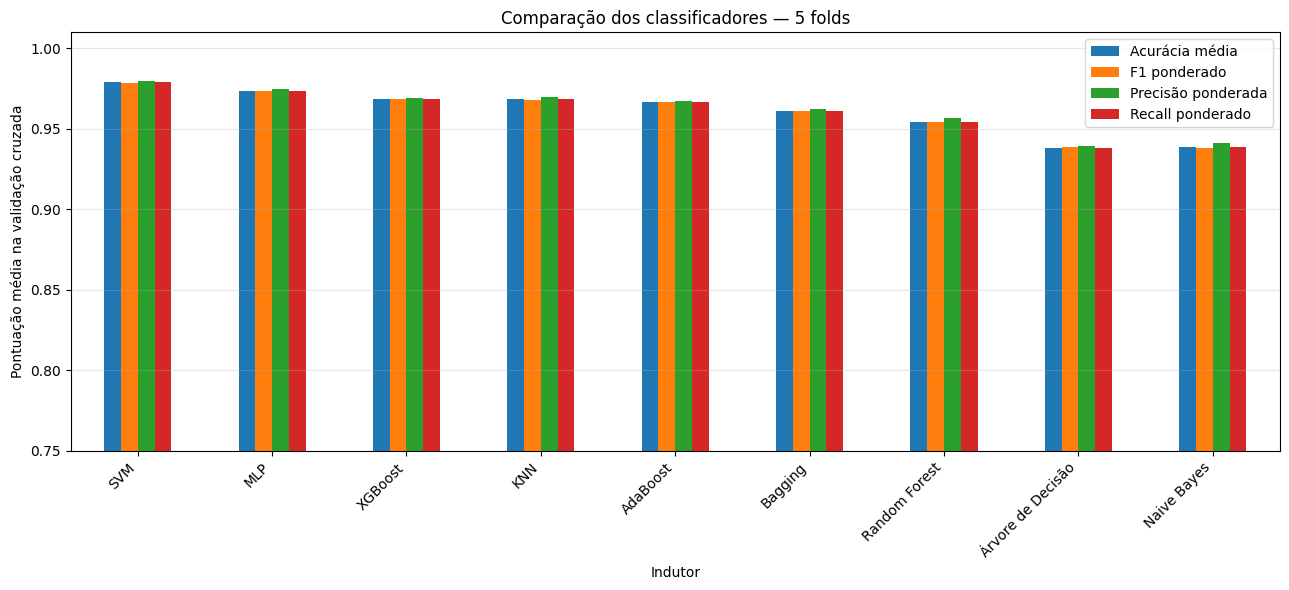

In [10]:
grafico = tabela_classificacao.set_index("Indutor")[
    ["Acurácia média", "F1 ponderado", "Precisão ponderada", "Recall ponderado"]
]

ax = grafico.plot(kind="bar", figsize=(13, 6))
ax.set_ylim(0.75, 1.01)
ax.set_ylabel("Pontuação média na validação cruzada")
ax.set_title("Comparação dos classificadores — 5 folds")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 9. Seleção do melhor modelo

Maior F1 ponderado.

In [11]:
nome_melhor_classificador = tabela_classificacao.loc[0, "Indutor"]
busca_melhor_classificador = buscas_classificacao[nome_melhor_classificador]
melhor_classificador = busca_melhor_classificador.best_estimator_

print("Melhor classificador:", nome_melhor_classificador)
print("Melhores parâmetros:")
display(busca_melhor_classificador.best_params_)

Melhor classificador: SVM
Melhores parâmetros:


{'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'rbf'}

## 10. Predições fora da amostra

`cross_val_predict` garante que cada instância seja predita por um modelo que não a
utilizou no treinamento daquele fold. Essas predições serão usadas na matriz de confusão
e no relatório por classe.

In [12]:
y_pred_oof = cross_val_predict(
    clone(melhor_classificador),
    X,
    y,
    cv=cv,
    n_jobs=N_JOBS,
    method="predict",
)

metricas_oof = pd.DataFrame({
    "métrica": [
        "Acurácia OOF",
        "F1 ponderado OOF",
        "Precisão ponderada OOF",
        "Recall ponderado OOF",
    ],
    "valor": [
        accuracy_score(y, y_pred_oof),
        f1_score(y, y_pred_oof, average="weighted", zero_division=0),
        precision_score(y, y_pred_oof, average="weighted", zero_division=0),
        recall_score(y, y_pred_oof, average="weighted", zero_division=0),
    ],
})

metricas_oof["valor"] = metricas_oof["valor"].round(4)
display(metricas_oof)

,métrica,valor
0,Acurácia OOF,0.9789
1,F1 ponderado OOF,0.9789
2,Precisão ponderada OOF,0.9789
3,Recall ponderado OOF,0.9789


## 11. A.2 — Matriz de confusão

As linhas representam as classes reais e as colunas representam as classes preditas.

,Predito: Maligno (0),Predito: Benigno (1)
Real: Maligno (0),204,8
Real: Benigno (1),4,353


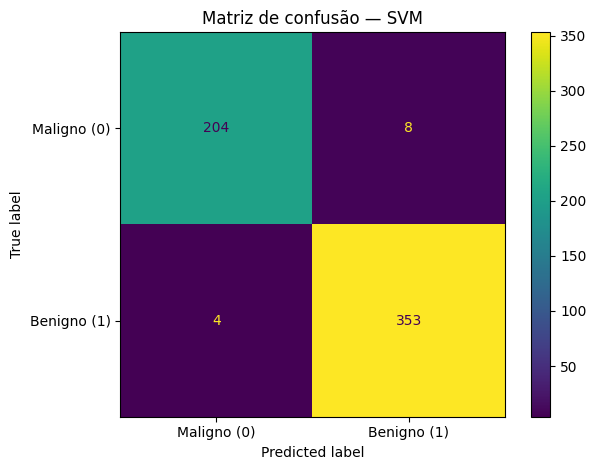

In [13]:
rotulos = [0, 1]
nomes_classes = ["Maligno (0)", "Benigno (1)"]

matriz = confusion_matrix(y, y_pred_oof, labels=rotulos)

matriz_df = pd.DataFrame(
    matriz,
    index=[f"Real: {nome}" for nome in nomes_classes],
    columns=[f"Predito: {nome}" for nome in nomes_classes],
)
display(matriz_df)

ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=nomes_classes,
).plot(values_format="d")
plt.title(f"Matriz de confusão — {nome_melhor_classificador}")
plt.tight_layout()
plt.show()

## 12. A.1 — Taxa de acerto de cada classe

Para uma classe específica, a taxa de acerto é:

\[
\text{taxa da classe} =
\frac{\text{acertos da classe}}{\text{total real da classe}}
\]

Essa medida corresponde ao **recall da classe**.

In [14]:
totais_por_classe = matriz.sum(axis=1)
acertos_por_classe = np.diag(matriz)
taxa_por_classe = acertos_por_classe / totais_por_classe

tabela_taxas_classes = pd.DataFrame({
    "Classe": nomes_classes,
    "Acertos": acertos_por_classe,
    "Total real": totais_por_classe,
    "Taxa de acerto": taxa_por_classe,
    "Taxa de acerto (%)": taxa_por_classe * 100,
})

tabela_taxas_classes["Taxa de acerto"] = tabela_taxas_classes["Taxa de acerto"].round(4)
tabela_taxas_classes["Taxa de acerto (%)"] = tabela_taxas_classes["Taxa de acerto (%)"].round(2)

display(tabela_taxas_classes)

,Classe,Acertos,Total real,Taxa de acerto,Taxa de acerto (%)
0,Maligno (0),204,212,0.9623,96.23
1,Benigno (1),353,357,0.9888,98.88


## 13. Relatório completo por classe

Este relatório ajuda a interpretar precisão, recall e F1 separadamente para maligno e benigno.

In [15]:
relatorio = classification_report(
    y,
    y_pred_oof,
    labels=rotulos,
    target_names=nomes_classes,
    output_dict=True,
    zero_division=0,
)

relatorio_df = pd.DataFrame(relatorio).T
display(relatorio_df.round(4))

,precision,recall,f1-score,support
Maligno (0),0.9808,0.9623,0.9714,212.0000
Benigno (1),0.9778,0.9888,0.9833,357.0000
accuracy,0.9789,0.9789,0.9789,0.9789
macro avg,0.9793,0.9755,0.9774,569.0000
weighted avg,0.9789,0.9789,0.9789,569.0000


## 14. A.3 — Parâmetros usados no melhor treinamento

Os nomes aparecem com o prefixo `model__` porque o estimador está dentro de um pipeline.

In [16]:
parametros_completos = busca_melhor_classificador.best_params_
parametros_limpos = {
    chave.replace("model__", ""): valor
    for chave, valor in parametros_completos.items()
}

print("Parâmetros completos do GridSearchCV:")
display(parametros_completos)

print("\nParâmetros do estimador, sem o prefixo do pipeline:")
display(parametros_limpos)

Parâmetros completos do GridSearchCV:


{'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'rbf'}


Parâmetros do estimador, sem o prefixo do pipeline:


{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}

## 15. A.4 — Há diferença significativa entre acurácia e F1-score?

O notebook apresenta duas leituras:

1. **diferença prática:** distância, em pontos percentuais, entre as médias;
2. **teste pareado entre os folds:** teste t pareado com nível de 5%.

A comparação estatística é complementar. Acurácia e F1 medem aspectos diferentes e não
devem ser tratadas como grandezas totalmente intercambiáveis.

In [17]:
avaliacao_melhor = cross_validate(
    clone(melhor_classificador),
    X,
    y,
    cv=cv,
    scoring=scoring_classificacao,
    n_jobs=N_JOBS,
)

acc_folds = avaliacao_melhor["test_accuracy"]
f1_folds = avaliacao_melhor["test_f1_weighted"]

media_acc = acc_folds.mean()
media_f1 = f1_folds.mean()
diferenca_absoluta = abs(media_acc - media_f1)
diferenca_pp = diferenca_absoluta * 100

if np.allclose(acc_folds, f1_folds):
    estatistica_t = 0.0
    p_valor = 1.0
else:
    estatistica_t, p_valor = ttest_rel(acc_folds, f1_folds)

conclusao_estatistica = (
    "há evidência estatística de diferença ao nível de 5%"
    if p_valor < 0.05
    else "não há evidência estatística de diferença ao nível de 5%"
)

comparacao_metricas = pd.DataFrame({
    "fold": np.arange(1, 6),
    "acurácia": acc_folds,
    "F1 ponderado": f1_folds,
    "diferença absoluta": np.abs(acc_folds - f1_folds),
})

display(comparacao_metricas.round(4))

print(f"Média da acurácia: {media_acc:.4f}")
print(f"Média do F1 ponderado: {media_f1:.4f}")
print(f"Diferença prática: {diferenca_pp:.2f} ponto(s) percentual(is)")
print(f"p-valor do teste t pareado: {p_valor:.4f}")
print("Conclusão:", conclusao_estatistica)

,fold,acurácia,F1 ponderado,diferença absoluta
0,1,0.9912,0.9912,0.0000
1,2,0.9649,0.9649,0.0000
2,3,0.9649,0.9645,0.0004
3,4,0.9912,0.9912,0.0000
4,5,0.9823,0.9822,0.0001


Média da acurácia: 0.9789
Média do F1 ponderado: 0.9788
Diferença prática: 0.01 ponto(s) percentual(is)
p-valor do teste t pareado: 0.3220
Conclusão: não há evidência estatística de diferença ao nível de 5%


## 16. Respostas finais da Atividade A

Execute a célula para gerar um texto pronto para transcrição no documento.

In [18]:
taxa_maligno = tabela_taxas_classes.loc[
    tabela_taxas_classes["Classe"] == "Maligno (0)",
    "Taxa de acerto (%)",
].iloc[0]

taxa_benigno = tabela_taxas_classes.loc[
    tabela_taxas_classes["Classe"] == "Benigno (1)",
    "Taxa de acerto (%)",
].iloc[0]

resposta_a4 = (
    f"A acurácia média foi {media_acc:.4f} e o F1 ponderado médio foi {media_f1:.4f}, "
    f"com diferença de {diferenca_pp:.2f} ponto(s) percentual(is). "
    f"O teste pareado produziu p={p_valor:.4f}; portanto, {conclusao_estatistica}."
)

print("=" * 80)
print("MELHOR RESULTADO OBSERVADO")
print("=" * 80)
print(f"Indutor: {nome_melhor_classificador}")
print(f"Acurácia média: {media_acc:.4f} ({media_acc * 100:.2f}%)")
print(f"F1 ponderado médio: {media_f1:.4f}")
print(
    "Precisão ponderada média: "
    f"{avaliacao_melhor['test_precision_weighted'].mean():.4f}"
)
print(
    "Recall ponderado médio: "
    f"{avaliacao_melhor['test_recall_weighted'].mean():.4f}"
)

print("\nA.1) Taxa de acerto de cada classe")
print(f"Maligno (0): {taxa_maligno:.2f}%")
print(f"Benigno (1): {taxa_benigno:.2f}%")

print("\nA.2) Matriz de confusão")
print(matriz)

print("\nA.3) Parâmetros utilizados")
print(parametros_limpos)

print("\nA.4) Comparação entre acurácia e F1-score")
print(resposta_a4)

MELHOR RESULTADO OBSERVADO
Indutor: SVM
Acurácia média: 0.9789 (97.89%)
F1 ponderado médio: 0.9788
Precisão ponderada média: 0.9795
Recall ponderado médio: 0.9789

A.1) Taxa de acerto de cada classe
Maligno (0): 96.23%
Benigno (1): 98.88%

A.2) Matriz de confusão
[[204   8]
 [  4 353]]

A.3) Parâmetros utilizados
{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}

A.4) Comparação entre acurácia e F1-score
A acurácia média foi 0.9789 e o F1 ponderado médio foi 0.9788, com diferença de 0.01 ponto(s) percentual(is). O teste pareado produziu p=0.3220; portanto, não há evidência estatística de diferença ao nível de 5%.


## 17. Ajuste final

Depois de concluir a avaliação, pode-se ajustar o melhor modelo em toda a base para
uso posterior. Esse ajuste não substitui as métricas de validação cruzada.

In [ ]:
modelo_final_classificacao = clone(melhor_classificador)
modelo_final_classificacao.fit(X, y)

print("Modelo final ajustado em todas as 569 instâncias.")